In [2]:
# **Importing Libraries**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, f_oneway

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, precision_recall_curve, average_precision_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryFocalCrossentropy
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import fbeta_score

In [3]:
# **Importing Dataset**
data = pd.read_csv('/Users/alfonsoqu/Desktop/ASU/2025Summer/DAT 490/cleaned_dataset.csv')

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())
print("\nFirst few rows:")
data.head()

Dataset shape: (111717, 41)

Column names:
['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date', 'is_canceled', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'order_delivered_customer_date', 'is_first_time_buyer', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date', 'handoff_delay', 'distance_km', 'product_id', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_id', 'review_score', 'delivered_late', 'delivery_delay']

First few rows:


,order_id,order_item_id,order_status,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,is_canceled,customer_id,customer_unique_id,customer_zip_code_prefix,...,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,delivered_late,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,delivered,2017-10-02,2017-10-02,2017-10-18,False,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,False,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,delivered,2018-07-24,2018-07-26,2018-08-13,False,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4.0,False,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,delivered,2018-08-08,2018-08-08,2018-09-04,False,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,False,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,delivered,2017-11-18,2017-11-18,2017-12-15,False,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,False,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,delivered,2018-02-13,2018-02-13,2018-02-26,False,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,e50934924e227544ba8246aeb3770dd4,5.0,False,-10.0


In [4]:
# **Data Exploration**
print("\nTarget variable distribution:")
print(data['is_canceled'].value_counts())
print("\nFirst-time buyer distribution:")
print(data['is_first_time_buyer'].value_counts())


Target variable distribution:
is_canceled
False    111191
True        526
Name: count, dtype: int64

First-time buyer distribution:
is_first_time_buyer
True     84451
False    27266
Name: count, dtype: int64


In [5]:
# **Pre-Processing**
# **Removing Unnecessary Columns**
# Keep relevant features for cancellation prediction and customer segmentation
data_processed = data.drop(columns=[
    'order_id',
    'order_item_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_estimated_delivery_date',
    'customer_id',
    'customer_unique_id',
    'customer_zip_code_prefix',
    'customer_lat',
    'customer_lng',
    'order_delivered_customer_date',
    'seller_zip_code_prefix',
    'seller_lat',
    'seller_lng',
    'shipping_limit_date',
    'order_delivered_carrier_date',
    'product_id',
    'review_id',
    'delivered_late',
    'delivery_delay',
    'review_score'
]).copy()

print("Data shape after column removal:", data_processed.shape)
print("\nRemaining columns:")
print(data_processed.columns.tolist())

Data shape after column removal: (111717, 19)

Remaining columns:
['is_canceled', 'customer_city', 'customer_state', 'is_first_time_buyer', 'seller_id', 'seller_city', 'seller_state', 'handoff_delay', 'distance_km', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [6]:
# **Removing NA Rows**
print("Missing values before cleaning:")
print(data_processed.isnull().sum())

data_processed = data_processed.dropna()
print("\nData shape after removing NA rows:", data_processed.shape)

Missing values before cleaning:
is_canceled                         0
customer_city                       0
customer_state                      0
is_first_time_buyer                 0
seller_id                           0
seller_city                         0
seller_state                        0
handoff_delay                    1161
distance_km                         0
product_category_name_english    1613
price                               0
freight_value                       0
product_name_length              1589
product_description_length       1589
product_photos_qty               1589
product_weight_g                   17
product_length_cm                  17
product_height_cm                  17
product_width_cm                   17
dtype: int64

Data shape after removing NA rows: (108983, 19)


In [7]:
# **Variable Selection**
# Target variable: is_canceled
# Keep is_first_time_buyer for segmentation analysis
X = data_processed.drop(columns=['is_canceled'])
y = data_processed['is_canceled']

print("Features for modeling:")
print(X.columns.tolist())
print(f"\nTarget variable distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Features for modeling:
['customer_city', 'customer_state', 'is_first_time_buyer', 'seller_id', 'seller_city', 'seller_state', 'handoff_delay', 'distance_km', 'product_category_name_english', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Target variable distribution:
is_canceled
False    108908
True         75
Name: count, dtype: int64


In [8]:
# **Encoding Variables**
# Define categorical and numerical features
categorical_features = [
    'customer_city',
    'customer_state',
    'seller_city',
    'seller_state',
    'seller_id',
    'product_category_name_english',
    'is_first_time_buyer',  # Include for segmentation
    'delivered_late'
]

numerical_features = [
    'handoff_delay',
    'distance_km',
    'price',
    'freight_value',
    'product_name_length',
    'product_description_length',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'review_score',
    'delivery_delay'
]

# Filter features that actually exist in the dataset
existing_categorical = [col for col in categorical_features if col in X.columns]
existing_numerical = [col for col in numerical_features if col in X.columns]

print("Categorical features to encode:", existing_categorical)
print("Numerical features to scale:", existing_numerical)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), existing_categorical),
    ('num', StandardScaler(), existing_numerical)
])

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

Categorical features to encode: ['customer_city', 'customer_state', 'seller_city', 'seller_state', 'seller_id', 'product_category_name_english', 'is_first_time_buyer']
Numerical features to scale: ['handoff_delay', 'distance_km', 'price', 'freight_value', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [9]:
# Basic counts
print("1. Raw counts:")
print(data['is_canceled'].value_counts())
print()

# Percentages
print("2. Percentages:")
print(data['is_canceled'].value_counts(normalize=True) * 100)
print()

1. Raw counts:
is_canceled
False    111191
True        526
Name: count, dtype: int64

2. Percentages:
is_canceled
False    99.529167
True      0.470833
Name: proportion, dtype: float64



In [10]:
# More detailed breakdown
total_orders = len(data)
canceled_orders = data['is_canceled'].sum()
not_canceled_orders = total_orders - canceled_orders

print("3. Detailed breakdown:")
print(f"Total orders: {total_orders}")
print(f"Canceled orders: {canceled_orders}")
print(f"Not canceled orders: {not_canceled_orders}")
print(f"Cancellation rate: {(canceled_orders/total_orders)*100:.2f}%")
print()

# Check data types to make sure we're reading correctly
print("4. Data type check:")
print(f"is_canceled column type: {data['is_canceled'].dtype}")
print(f"Unique values in is_canceled: {data['is_canceled'].unique()}")
print()

3. Detailed breakdown:
Total orders: 111717
Canceled orders: 526
Not canceled orders: 111191
Cancellation rate: 0.47%

4. Data type check:
is_canceled column type: bool
Unique values in is_canceled: [False  True]



In [11]:
# If the column contains True/False as strings instead of booleans
if data['is_canceled'].dtype == 'object':
    print("5. String value analysis:")
    print(data['is_canceled'].value_counts())
    print("Converting to boolean...")
    data['is_canceled'] = data['is_canceled'].map({'True': True, 'False': False, True: True, False: False})
    print("After conversion:")
    print(data['is_canceled'].value_counts())
    print()

# Cross-check with order_status if available
if 'order_status' in data.columns:
    print("6. Cross-check with order_status:")
    print(data['order_status'].value_counts())
    print()

    # Check relationship between order_status and is_canceled
    print("7. Relationship between order_status and is_canceled:")
    print(pd.crosstab(data['order_status'], data['is_canceled'], margins=True))
    print()

# Check for any patterns by customer type
if 'is_first_time_buyer' in data.columns:
    print("8. Cancellation by customer type:")
    cancellation_by_type = data.groupby('is_first_time_buyer')['is_canceled'].agg(['count', 'sum', 'mean'])
    cancellation_by_type.columns = ['Total Orders', 'Canceled Orders', 'Cancellation Rate']
    print(cancellation_by_type)
    print()

# Sample some canceled orders to verify
if canceled_orders > 0:
    print("9. Sample of canceled orders:")
    canceled_sample = data[data['is_canceled'] == True].head()
    print(canceled_sample[['order_id', 'is_canceled', 'order_status'] if 'order_status' in data.columns else ['order_id', 'is_canceled']])
else:
    print("9. NO CANCELED ORDERS FOUND!")
    print("This explains why your models have AP = 0.00")
    print("Recommendations:")
    print("- Check if 'is_canceled' column is correctly defined")
    print("- Verify data preprocessing steps")
    print("- Consider using a different target variable")
    print("- Collect more data with actual cancellations")

6. Cross-check with order_status:
order_status
delivered      109307
shipped          1174
canceled          526
invoiced          354
processing        346
unavailable         7
approved            3
Name: count, dtype: int64

7. Relationship between order_status and is_canceled:
is_canceled    False  True     All
order_status                      
approved           3     0       3
canceled           0   526     526
delivered     109307     0  109307
invoiced         354     0     354
processing       346     0     346
shipped         1174     0    1174
unavailable        7     0       7
All           111191   526  111717

8. Cancellation by customer type:
                     Total Orders  Canceled Orders  Cancellation Rate
is_first_time_buyer                                                  
False                       27266              134           0.004915
True                        84451              392           0.004642

9. Sample of canceled orders:
                      

In [12]:
# **Getting Feature Names**
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

# Get column names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(existing_categorical)
all_feature_names = list(cat_feature_names) + existing_numerical

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_feature_names)

print("Final feature set shape:", X_train_df.shape)

Final feature set shape: (87186, 7281)


In [13]:
# **Applying SMOTE**
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)

print("After SMOTE - Training set shape:", X_train_resampled.shape)
print("After SMOTE - Target distribution:")
print(pd.Series(y_train_resampled).value_counts())

After SMOTE - Training set shape: (174252, 7281)
After SMOTE - Target distribution:
is_canceled
False    87126
True     87126
Name: count, dtype: int64


In [14]:
# **Applying StratifiedKFold**
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# **Focusing Recall for the Positive Cancellations**
recall_scorer = make_scorer(recall_score, pos_label=True)

In [15]:
# PREPARE DATA FOR CLUSTERING
# Select features for clustering (behavioral and geographical patterns)
clustering_features = [
    'customer_state', 'customer_city', 'seller_state', 'seller_city',
    'product_category_name_english', 'price', 'freight_value',
    'product_weight_g', 'distance_km', 'handoff_delay',
    'is_first_time_buyer', 'review_score'
]

# Filter features that exist in the dataset
available_features = [col for col in clustering_features if col in data.columns]
print(f"Available features for clustering: {available_features}")

# Create clustering dataset
cluster_data = data[available_features + ['is_canceled']].copy()
cluster_data = cluster_data.dropna()

print(f"Data shape for clustering: {cluster_data.shape}")
print(f"Missing values: {cluster_data.isnull().sum().sum()}")

Available features for clustering: ['customer_state', 'customer_city', 'seller_state', 'seller_city', 'product_category_name_english', 'price', 'freight_value', 'product_weight_g', 'distance_km', 'handoff_delay', 'is_first_time_buyer', 'review_score']
Data shape for clustering: (108087, 13)
Missing values: 0


In [16]:
# FEATURE ENGINEERING FOR CLUSTERING
# Create additional behavioral features
if 'price' in cluster_data.columns and 'freight_value' in cluster_data.columns:
    cluster_data['total_cost'] = cluster_data['price'] + cluster_data['freight_value']
    cluster_data['freight_ratio'] = cluster_data['freight_value'] / (cluster_data['price'] + 1)

if 'distance_km' in cluster_data.columns:
    cluster_data['is_long_distance'] = (cluster_data['distance_km'] > cluster_data['distance_km'].median()).astype(int)

if 'handoff_delay' in cluster_data.columns:
    cluster_data['has_handoff_delay'] = (cluster_data['handoff_delay'] > 0).astype(int)

# Separate numerical and categorical features
numerical_features = cluster_data.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col != 'is_canceled']

categorical_features = cluster_data.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_features = [col for col in categorical_features if col != 'is_canceled']

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['price', 'freight_value', 'product_weight_g', 'distance_km', 'handoff_delay', 'review_score', 'total_cost', 'freight_ratio', 'is_long_distance', 'has_handoff_delay']
Categorical features: ['customer_state', 'customer_city', 'seller_state', 'seller_city', 'product_category_name_english', 'is_first_time_buyer']


In [17]:
# ENCODE CATEGORICAL VARIABLES
# For clustering, we'll use Label Encoding for categorical variables
# (Alternative: One-hot encoding, but it can create too many dimensions)
cluster_data_encoded = cluster_data.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    cluster_data_encoded[col] = le.fit_transform(cluster_data_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Prepare final clustering features
clustering_cols = numerical_features + categorical_features
X_cluster = cluster_data_encoded[clustering_cols]

Encoded customer_state: 27 unique values
Encoded customer_city: 4015 unique values
Encoded seller_state: 22 unique values
Encoded seller_city: 582 unique values
Encoded product_category_name_english: 71 unique values
Encoded is_first_time_buyer: 2 unique values


In [18]:
# STANDARDIZE FEATURES
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=clustering_cols)

print(f"Scaled data shape: {X_cluster_scaled_df.shape}")
print("Standardization completed")

Scaled data shape: (108087, 16)
Standardization completed


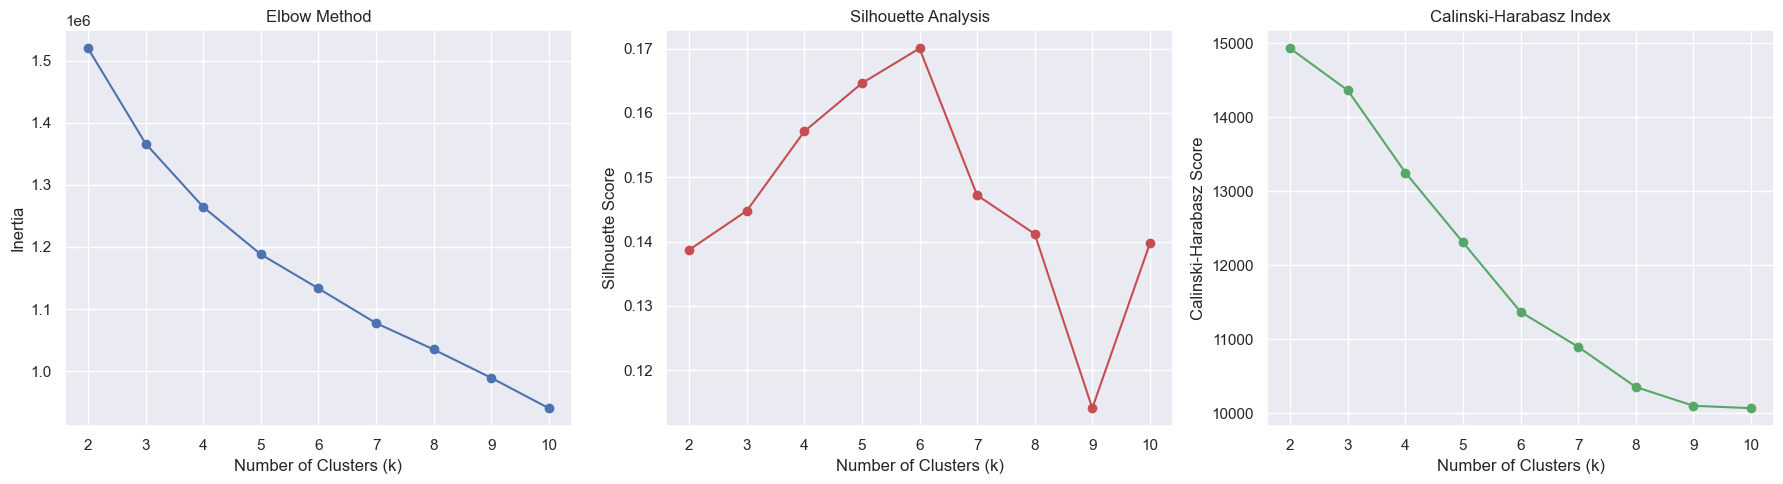

Optimal k by Silhouette Score: 6 (score: 0.170)
Optimal k by Calinski-Harabasz: 2 (score: 14930.6)


In [19]:
# DETERMINE OPTIMAL NUMBER OF CLUSTERS
# Elbow method and Silhouette analysis
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(X_cluster_scaled, cluster_labels))

# Plot evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True)

# Calinski-Harabasz score
axes[2].plot(k_range, calinski_scores, 'go-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]

print(f"Optimal k by Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"Optimal k by Calinski-Harabasz: {optimal_k_calinski} (score: {max(calinski_scores):.1f})")

# Use the better silhouette score
optimal_k = optimal_k_silhouette

In [20]:
# PERFORM K-MEANS CLUSTERING
# Fit final K-means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to original data
cluster_data_encoded['cluster'] = cluster_labels
cluster_data['cluster'] = cluster_labels

print(f"Clustering completed with {optimal_k} clusters")
print(f"Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Clustering completed with 6 clusters
Cluster distribution:
0    14076
1    44119
2     5944
3     3146
4     5521
5    35281
Name: count, dtype: int64


In [21]:
# CLUSTER CHARACTERIZATION
# Analyze cluster characteristics
cluster_summary = cluster_data.groupby('cluster').agg({
    'is_canceled': ['count', 'sum', 'mean'],
    'price': 'mean',
    'freight_value': 'mean',
    'distance_km': 'mean',
    'review_score': 'mean'
}).round(3)

cluster_summary.columns = [f"{col[0]}_{col[1]}" for col in cluster_summary.columns]
cluster_summary = cluster_summary.rename(columns={
    'is_canceled_count': 'Total_Orders',
    'is_canceled_sum': 'Canceled_Orders',
    'is_canceled_mean': 'Cancellation_Rate',
    'price_mean': 'Avg_Price',
    'freight_value_mean': 'Avg_Freight',
    'distance_km_mean': 'Avg_Distance',
    'review_score_mean': 'Avg_Review_Score'
})

print("Cluster Summary Statistics:")
print(cluster_summary)

Cluster Summary Statistics:
         Total_Orders  Canceled_Orders  Cancellation_Rate  Avg_Price  \
cluster                                                                
0               14076                9              0.001    102.263   
1               44119               31              0.001     81.541   
2                5944                4              0.001     98.535   
3                3146                0              0.000    660.019   
4                5521                3              0.001    207.703   
5               35281               18              0.001     87.072   

         Avg_Freight  Avg_Distance  Avg_Review_Score  
cluster                                               
0             20.462       690.741             4.223  
1             13.095       196.052             4.186  
2             18.425       590.732             3.488  
3             32.450       768.010             4.140  
4             49.209       670.983             3.917  
5         

In [22]:
# BEHAVIORAL DIFFERENCES ANALYSIS

# Statistical tests for differences between clusters
# Chi-square test for cancellation rates
contingency_table = pd.crosstab(cluster_data['cluster'], cluster_data['is_canceled'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for cancellation differences between clusters:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

# ANOVA for numerical variables
numerical_vars_to_test = ['price', 'freight_value', 'distance_km']
for var in numerical_vars_to_test:
    if var in cluster_data.columns:
        cluster_groups = [cluster_data[cluster_data['cluster'] == i][var].dropna()
                         for i in range(optimal_k)]

        # Remove empty groups
        cluster_groups = [group for group in cluster_groups if len(group) > 0]

        if len(cluster_groups) > 1:
            f_stat, p_val = f_oneway(*cluster_groups)
            print(f"ANOVA for {var}: F={f_stat:.4f}, p={p_val:.6f}")

Chi-square test for cancellation differences between clusters:
Chi-square statistic: 3.2494
P-value: 0.661590
Significant difference: No
ANOVA for price: F=34092.5203, p=0.000000
ANOVA for freight_value: F=18344.0403, p=0.000000
ANOVA for distance_km: F=12811.8557, p=0.000000


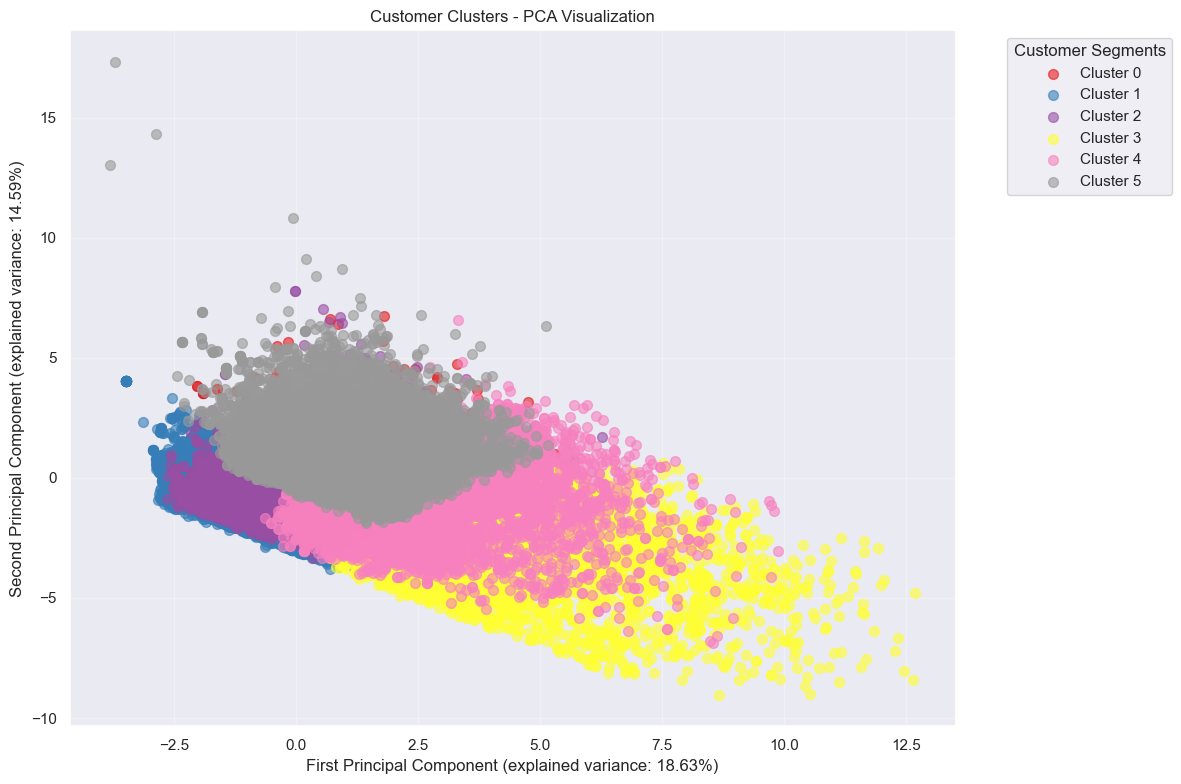

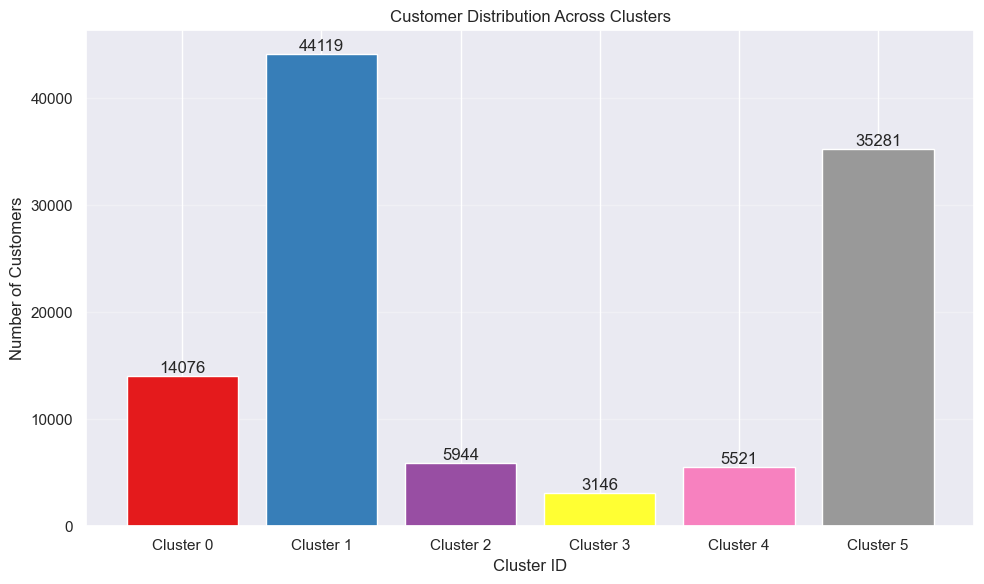

In [23]:
# CLUSTER VISUALIZATION
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create discrete color map for clusters
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

plt.figure(figsize=(12, 8))

# Plot each cluster separately for discrete legend
for i in range(optimal_k):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=50)

plt.xlabel(f'First Principal Component (explained variance: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Second Principal Component (explained variance: {pca.explained_variance_ratio_[1]:.2%})')
plt.title('Customer Clusters - PCA Visualization')
plt.legend(title='Customer Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional visualization: Cluster distribution
plt.figure(figsize=(10, 6))
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
bars = plt.bar(range(optimal_k), cluster_counts.values, color=colors[:optimal_k])
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution Across Clusters')
plt.xticks(range(optimal_k), [f'Cluster {i}' for i in range(optimal_k)])

# Add value labels on bars
for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# CLUSTER PROFILES
for cluster_id in range(optimal_k):
    cluster_subset = cluster_data[cluster_data['cluster'] == cluster_id]
    print(f"\n--- CLUSTER {cluster_id} PROFILE ---")
    print(f"Size: {len(cluster_subset)} customers ({len(cluster_subset)/len(cluster_data)*100:.1f}%)")
    print(f"Cancellation Rate: {cluster_subset['is_canceled'].mean():.3f}")

    # Most common categorical values
    for cat_col in ['customer_state', 'product_category_name_english']:
        if cat_col in cluster_subset.columns:
            top_category = cluster_subset[cat_col].mode().iloc[0] if len(cluster_subset[cat_col].mode()) > 0 else "N/A"
            print(f"Most common {cat_col}: {top_category}")

    # Average numerical values
    numerical_summary = cluster_subset[numerical_features].mean()
    print("Average values:")
    for col, val in numerical_summary.items():
        print(f"  {col}: {val:.2f}")


--- CLUSTER 0 PROFILE ---
Size: 14076 customers (13.0%)
Cancellation Rate: 0.001
Most common customer_state: sp
Most common product_category_name_english: computers_accessories
Average values:
  price: 102.26
  freight_value: 20.46
  product_weight_g: 1689.63
  distance_km: 690.74
  handoff_delay: -4.39
  review_score: 4.22
  total_cost: 122.72
  freight_ratio: 0.31
  is_long_distance: 0.72
  has_handoff_delay: 0.00

--- CLUSTER 1 PROFILE ---
Size: 44119 customers (40.8%)
Cancellation Rate: 0.001
Most common customer_state: sp
Most common product_category_name_english: bed_bath_table
Average values:
  price: 81.54
  freight_value: 13.09
  product_weight_g: 1267.99
  distance_km: 196.05
  handoff_delay: -3.85
  review_score: 4.19
  total_cost: 94.64
  freight_ratio: 0.26
  is_long_distance: 0.03
  has_handoff_delay: 0.00

--- CLUSTER 2 PROFILE ---
Size: 5944 customers (5.5%)
Cancellation Rate: 0.001
Most common customer_state: sp
Most common product_category_name_english: computers_acc

In [30]:
# BUSINESS INSIGHTS
# Identify high-risk and low-risk clusters
cluster_risk = cluster_summary['Cancellation_Rate'].sort_values(ascending=False)
high_risk_clusters = cluster_risk.head(2).index.tolist()
low_risk_clusters = cluster_risk.tail(2).index.tolist()

print(f"HIGH-RISK CLUSTERS (highest cancellation rates): {high_risk_clusters}")
for cluster_id in high_risk_clusters:
    rate = cluster_summary.loc[cluster_id, 'Cancellation_Rate']
    count = cluster_summary.loc[cluster_id, 'Total_Orders']
    print(f"  Cluster {cluster_id}: {rate:.3f} cancellation rate ({count} orders)")

print(f"\nLOW-RISK CLUSTERS (lowest cancellation rates): {low_risk_clusters}")
for cluster_id in low_risk_clusters:
    rate = cluster_summary.loc[cluster_id, 'Cancellation_Rate']
    count = cluster_summary.loc[cluster_id, 'Total_Orders']
    print(f"  Cluster {cluster_id}: {rate:.3f} cancellation rate ({count} orders)")

HIGH-RISK CLUSTERS (highest cancellation rates): [0, 1]
  Cluster 0: 0.001 cancellation rate (14076 orders)
  Cluster 1: 0.001 cancellation rate (44119 orders)

LOW-RISK CLUSTERS (lowest cancellation rates): [5, 3]
  Cluster 5: 0.001 cancellation rate (35281 orders)
  Cluster 3: 0.000 cancellation rate (3146 orders)


In [31]:
# **Logistic Regression**
# **Creating the Best Model**
# Logistic regression model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Hyperparameter grid (penalty type and C values)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']  # Try both L1 and L2 regularization
}

# Grid search setup
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit model
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# Extract best model and params
best_log_reg = grid_log_reg.best_estimator_
print("Best Parameters:", grid_log_reg.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.01, penalty=l1; total time=  27.5s
[CV] END .................................C=0.01, penalty=l1; total time=  27.6s
[CV] END .................................C=0.01, penalty=l1; total time=  28.3s
[CV] END .................................C=0.01, penalty=l1; total time=  26.6s
[CV] END .................................C=0.01, penalty=l1; total time=  26.4s
[CV] END .................................C=0.01, penalty=l2; total time=  24.4s
[CV] END .................................C=0.01, penalty=l2; total time=  25.3s
[CV] END .................................C=0.01, penalty=l2; total time=  24.6s
[CV] END .................................C=0.01, penalty=l2; total time=  26.5s
[CV] END .................................C=0.01, penalty=l2; total time=  26.3s
[CV] END ..................................C=0.1, penalty=l1; total time=  37.8s
[CV] END ..................................C=0.1,

In [12]:
# **Testing the Model**
# Predict probabilities
y_proba_logreg = best_log_reg.predict_proba(X_test_df)[:, 1]
# === Threshold Optimization ===
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logreg)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-6)
optimal_threshold_logreg = thresholds[np.argmax(f2_scores)]
print(f"\nOptimal Threshold (LogReg): {optimal_threshold_logreg:.4f}")

# Apply optimal threshold
y_pred_logreg_opt = (y_proba_logreg >= optimal_threshold_logreg).astype(int)


Optimal Threshold (LogReg): 0.8877



Classification Report (Logistic Regression):
              precision    recall  f1-score   support

       False       1.00      0.99      0.99     21782
        True       0.01      0.13      0.02        15

    accuracy                           0.99     21797
   macro avg       0.50      0.56      0.51     21797
weighted avg       1.00      0.99      0.99     21797

ROC-AUC Score: 0.6663


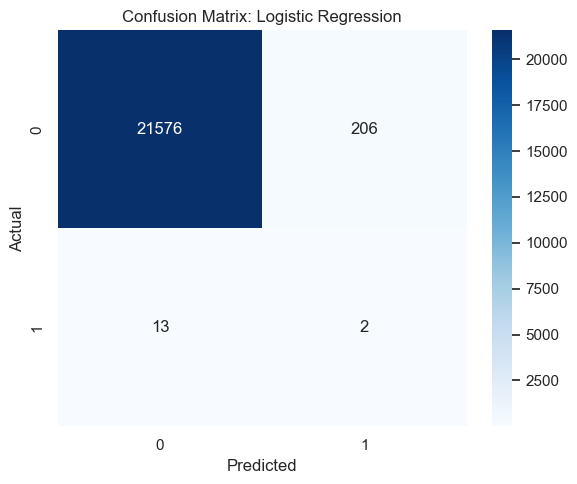

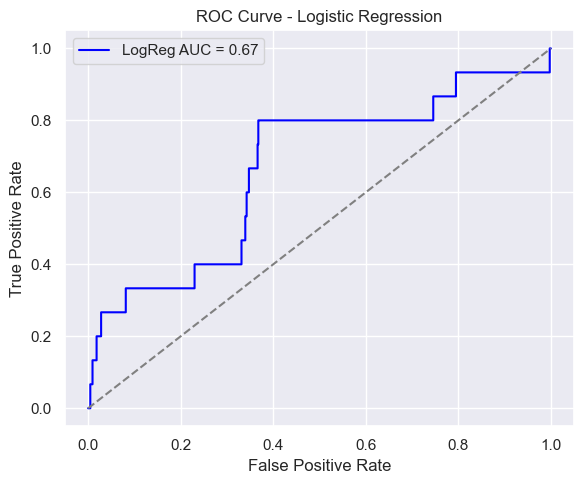

In [13]:
# Metrics
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg_opt))

roc_auc = roc_auc_score(y_test, y_proba_logreg)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# **Decision Tree**
# **Creating the Best Model**
# Define the Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search
grid_tree = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_tree,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit to the resampled training set
grid_tree.fit(X_train_resampled, y_train_resampled)

# Best model and parameters
best_tree = grid_tree.best_estimator_
print("Best Parameters:", grid_tree.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  25.7s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  24.2s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  23.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  23.5s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  24.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  24.8s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.5s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.6s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  23.9s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time=  24.6s
[CV] END .criterion=gini, max_depth=10, min_samples_split=10; total time=  27.9s
[CV] END .criterion=gini, max_depth=10, min_samp

In [15]:
# **Evaluating the Model**
# Predict probabilities
y_proba_tree = best_tree.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_tree, recall_tree, thresholds_tree = precision_recall_curve(y_test, y_proba_tree)
f2_scores_tree = 5 * (precision_tree * recall_tree) / (4 * precision_tree + recall_tree + 1e-6)
optimal_threshold_tree = thresholds_tree[np.argmax(f2_scores_tree)]
print(f"\nOptimal Threshold (Decision Tree): {optimal_threshold_tree:.4f}")

# Apply optimal threshold
y_pred_tree_opt = (y_proba_tree >= optimal_threshold_tree).astype(int)

# Metrics
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree_opt))

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
print(f"ROC-AUC Score (Tree): {roc_auc_tree:.4f}")


Optimal Threshold (Decision Tree): 0.0000

Classification Report (Decision Tree):
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     21782
        True       0.00      1.00      0.00        15

    accuracy                           0.00     21797
   macro avg       0.00      0.50      0.00     21797
weighted avg       0.00      0.00      0.00     21797

ROC-AUC Score (Tree): 0.4894


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


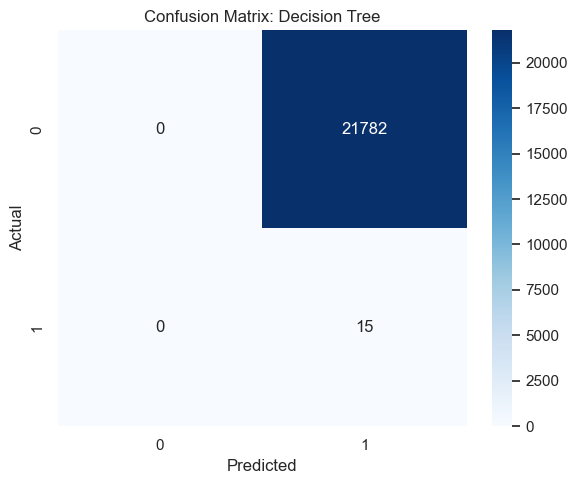

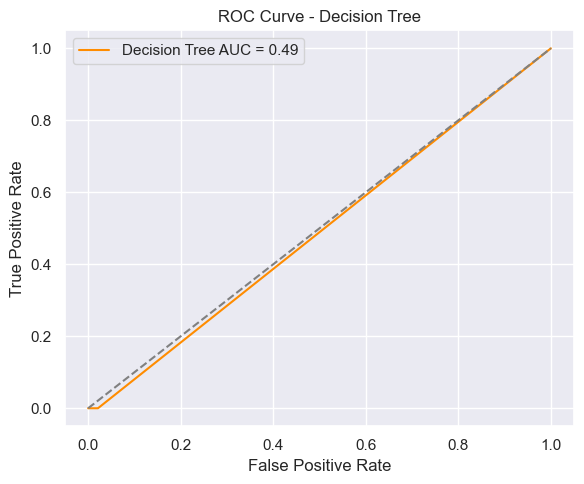

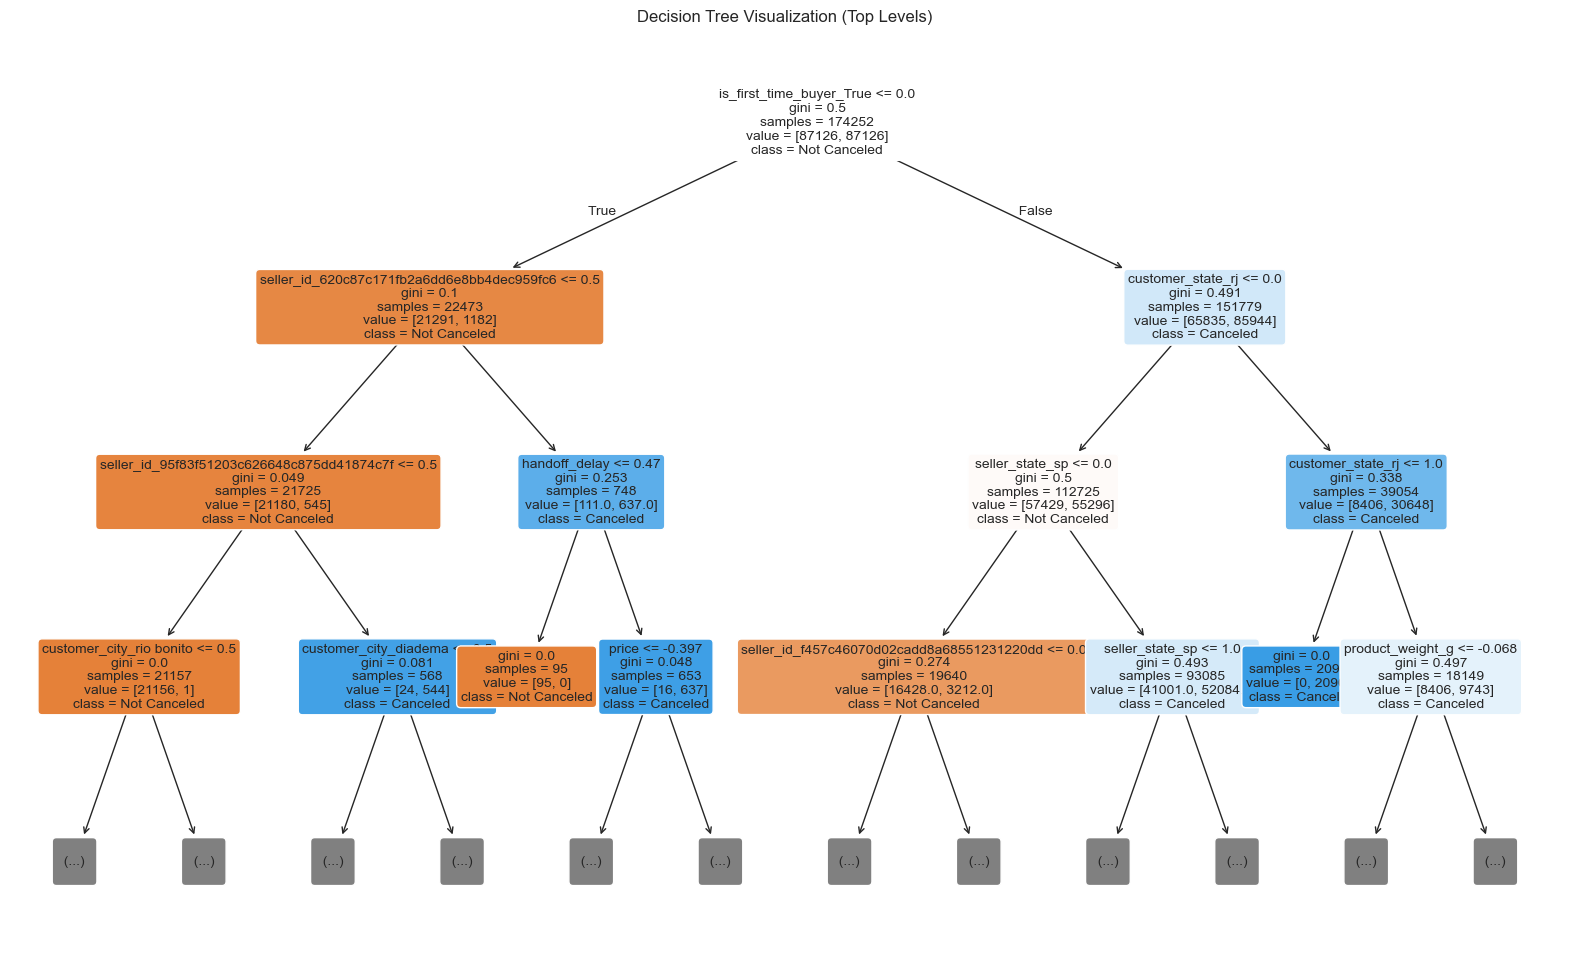

In [16]:
# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.figure(figsize=(6, 5))
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {roc_auc_tree:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Visualizing the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(
    best_tree,
    feature_names=all_feature_names,
    class_names=['Not Canceled', 'Canceled'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # limit depth for readability, remove or increase to see more
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

In [17]:
# **Random Forest**
# **Creating the Best Model**
# Random Forest
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']  # Helps handle imbalance without SMOTE here, but still okay if you keep SMOTE
}

grid_rf = GridSearchCV(
                        estimator=rf_clf,
                        param_grid=param_grid_rf,
                        scoring=recall_scorer,
                        cv=stratified_cv,
                        verbose=2,
                        n_jobs=1
                    )

grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  39.0s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  36.8s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  41.1s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  35.8s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time=  37.6s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  53.0s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  59.5s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  57.1s
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time=  5


Optimal Threshold (Random Forest): 0.4895

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     21782
        True       0.02      0.07      0.03        15

    accuracy                           1.00     21797
   macro avg       0.51      0.53      0.51     21797
weighted avg       1.00      1.00      1.00     21797

ROC-AUC Score (Random Forest): 0.6449


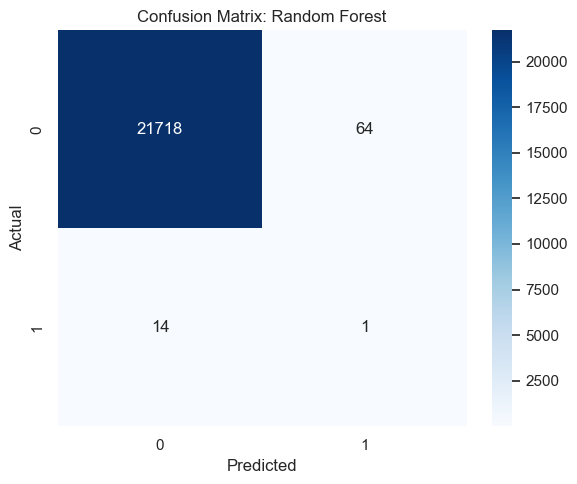

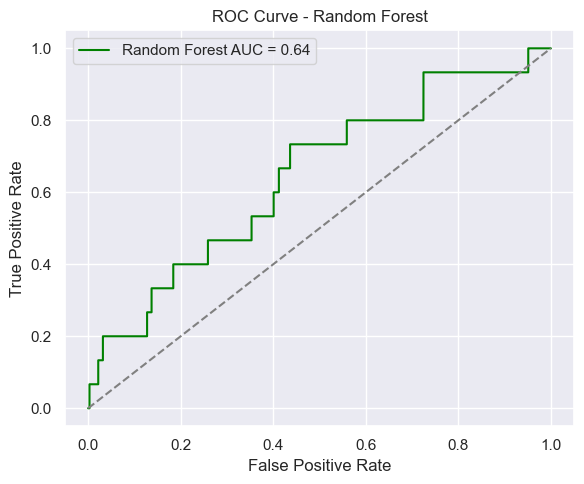

In [18]:
# **Evaluating the Model**
# Predict probabilities
y_proba_rf = best_rf.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
f2_scores_rf = 5 * (precision_rf * recall_rf) / (4 * precision_rf + recall_rf + 1e-6)
optimal_threshold_rf = thresholds_rf[np.argmax(f2_scores_rf)]
print(f"\nOptimal Threshold (Random Forest): {optimal_threshold_rf:.4f}")

# Apply optimal threshold
y_pred_rf_opt = (y_proba_rf >= optimal_threshold_rf).astype(int)

# Metrics
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf_opt))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# **XGBoost**
# **Creating the Model**
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
                        estimator=xgb_clf,
                        param_grid=param_grid_xgb,
                        scoring=recall_scorer,
                        cv=stratified_cv,
                        verbose=2,
                        n_jobs=1
                        )

grid_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb = grid_xgb.best_estimator_
print("Best Parameters (XGBoost):", grid_xgb.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:34:28] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  50.4s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [15:35:14] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  45.1s


...

[CV] END learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=  53.3s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:40:40] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=  53.8s


/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [18:41:30] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters (XGBoost): {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}


In [21]:
# **Evaluating the Model**
# Predict probabilities
y_proba_xgb = best_xgb.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)
f2_scores_xgb = 5 * (precision_xgb * recall_xgb) / (4 * precision_xgb + recall_xgb + 1e-6)
optimal_threshold_xgb = thresholds_xgb[np.argmax(f2_scores_xgb)]
print(f"\nOptimal Threshold (XGBoost): {optimal_threshold_xgb:.4f}")

# Apply threshold
y_pred_xgb_opt = (y_proba_xgb >= optimal_threshold_xgb).astype(int)


Optimal Threshold (XGBoost): 0.0028



Classification Report (XGBoost):
              precision    recall  f1-score   support

       False       1.00      0.97      0.99     21782
        True       0.00      0.13      0.01        15

    accuracy                           0.97     21797
   macro avg       0.50      0.55      0.50     21797
weighted avg       1.00      0.97      0.98     21797

ROC-AUC Score (XGBoost): 0.5715


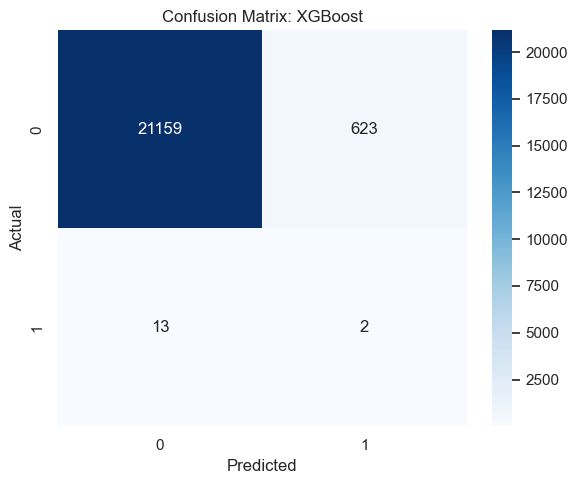

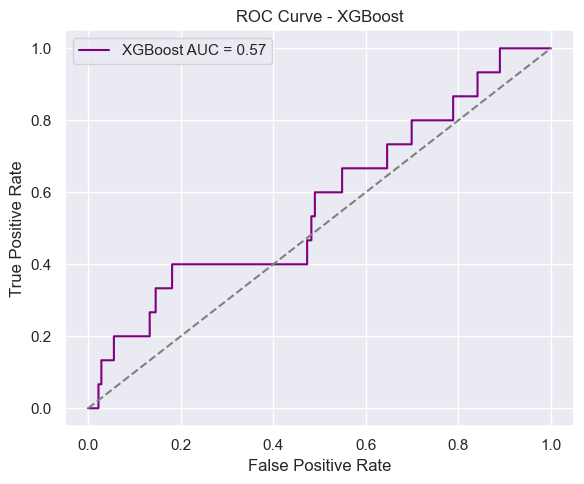

In [22]:
# Metrics
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb_opt))

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score (XGBoost): {roc_auc_xgb:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.2f}", color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# **ANN**
# **Creating the Model**
# Define the ANN model
def create_complex_ann():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_resampled.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    focal_loss = BinaryFocalCrossentropy(gamma=2.0)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=focal_loss, metrics=['Recall'])
    return model

# Wrap in KerasClassifier for calibration
keras_clf = KerasClassifier(model=create_complex_ann, epochs=15, batch_size=32, verbose=2)
keras_clf.fit(X_train_resampled, y_train_resampled)

/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
5446/5446 - 26s - 5ms/step - Recall: 0.9820 - loss: 0.0177
Epoch 2/15
5446/5446 - 25s - 5ms/step - Recall: 0.9945 - loss: 0.0065
Epoch 3/15
5446/5446 - 26s - 5ms/step - Recall: 0.9964 - loss: 0.0049
Epoch 4/15
5446/5446 - 25s - 5ms/step - Recall: 0.9969 - loss: 0.0039
Epoch 5/15
5446/5446 - 24s - 4ms/step - Recall: 0.9977 - loss: 0.0033
Epoch 6/15
5446/5446 - 22s - 4ms/step - Recall: 0.9983 - loss: 0.0027
Epoch 7/15
5446/5446 - 23s - 4ms/step - Recall: 0.9982 - loss: 0.0029
Epoch 8/15
5446/5446 - 23s - 4ms/step - Recall: 0.9984 - loss: 0.0022
Epoch 9/15
5446/5446 - 24s - 4ms/step - Recall: 0.9987 - loss: 0.0022
Epoch 10/15
5446/5446 - 24s - 4ms/step - Recall: 0.9990 - loss: 0.0018
Epoch 11/15
5446/5446 - 22s - 4ms/step - Recall: 0.9990 - loss: 0.0020
Epoch 12/15
5446/5446 - 23s - 4ms/step - Recall: 0.9991 - loss: 0.0019
Epoch 13/15
5446/5446 - 23s - 4ms/step - Recall: 0.9993 - loss: 0.0016
Epoch 14/15
5446/5446 - 23s - 4ms/step - Recall: 0.9993 - loss: 0.0012
Epoch 15/15
544

KerasClassifier(
	model=<function create_complex_ann at 0x32296e980>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=2
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=15
	class_weight=None
)

In [24]:
# **Evaluating the Model**
# Predict probabilities
y_proba_ann = keras_clf.predict_proba(X_test_df)[:, 1]

# Threshold Optimization
precision_ann, recall_ann, thresholds_ann = precision_recall_curve(y_test, y_proba_ann)
f2_scores_ann = 5 * (precision_ann * recall_ann) / (4 * precision_ann + recall_ann + 1e-6)
optimal_threshold_ann = thresholds_ann[np.argmax(f2_scores_ann)]
print(f"\nOptimal Threshold (ANN): {optimal_threshold_ann:.4f}")

# Apply threshold
y_pred_ann_opt = (y_proba_ann >= optimal_threshold_ann).astype(int)

682/682 - 1s - 904us/step

Optimal Threshold (ANN): 0.0362



Classification Report (ANN):
              precision    recall  f1-score   support

       False       1.00      0.97      0.98     21782
        True       0.00      0.07      0.00        15

    accuracy                           0.97     21797
   macro avg       0.50      0.52      0.49     21797
weighted avg       1.00      0.97      0.98     21797

ROC-AUC Score (ANN): 0.5309


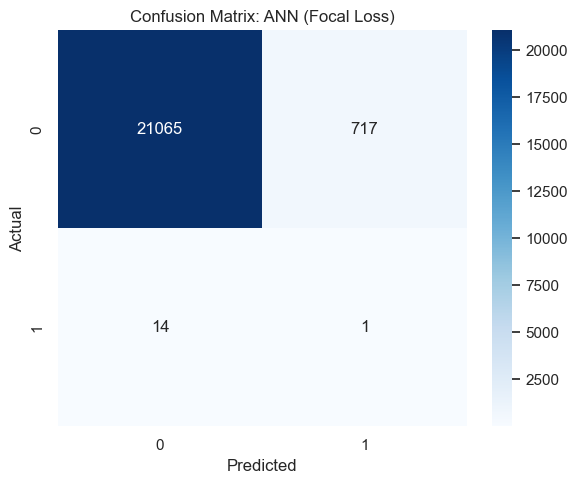

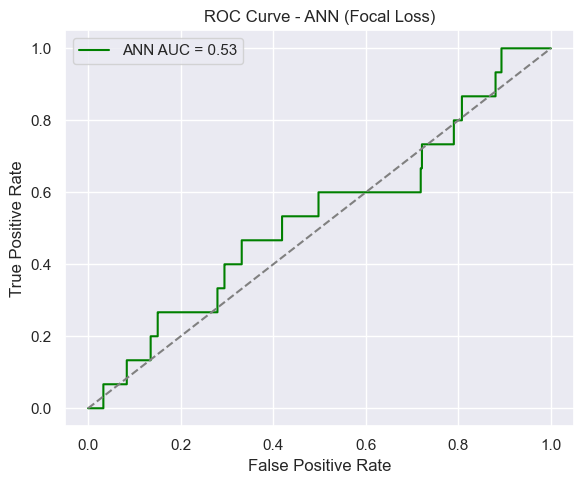

In [25]:
# Metrics
print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann_opt))

roc_auc_ann = roc_auc_score(y_test, y_proba_ann)
print(f"ROC-AUC Score (ANN): {roc_auc_ann:.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ann_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: ANN (Focal Loss)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
plt.figure(figsize=(6, 5))
plt.plot(fpr_ann, tpr_ann, label=f"ANN AUC = {roc_auc_ann:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN (Focal Loss)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# **Customer Segmentation Analysis**
# Analyze cancellation behavior by customer segments
print("=== CUSTOMER SEGMENTATION ANALYSIS ===")

# Analyze cancellation rates by first-time vs repeat buyers
segmentation_analysis = data_processed.groupby('is_first_time_buyer')['is_canceled'].agg(['count', 'sum', 'mean']).round(4)
segmentation_analysis.columns = ['Total_Orders', 'Canceled_Orders', 'Cancellation_Rate']
print("\nCancellation Analysis by Customer Type:")
print(segmentation_analysis)

# Analyze by region (state)
region_analysis = data_processed.groupby('customer_state')['is_canceled'].agg(['count', 'sum', 'mean']).round(4)
region_analysis.columns = ['Total_Orders', 'Canceled_Orders', 'Cancellation_Rate']
region_analysis = region_analysis.sort_values('Cancellation_Rate', ascending=False)
print("\nTop 10 States by Cancellation Rate:")
print(region_analysis.head(10))

# Statistical test for difference between first-time and repeat buyers
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data_processed['is_first_time_buyer'], data_processed['is_canceled'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square test for independence:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# **Model Comparison**
# **Classification Reports**
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logreg_opt))

print("\nClassification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree_opt))

print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf_opt))

print("\nClassification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb_opt))

print("\nClassification Report - ANN")
print(classification_report(y_test, y_pred_ann_opt))

=== CUSTOMER SEGMENTATION ANALYSIS ===

Cancellation Analysis by Customer Type:
                     Total_Orders  Canceled_Orders  Cancellation_Rate
is_first_time_buyer                                                  
False                       26580                7             0.0003
True                        82403               68             0.0008

Top 10 States by Cancellation Rate:
                Total_Orders  Canceled_Orders  Cancellation_Rate
customer_state                                                  
to                       298                1             0.0034
pi                       510                1             0.0020
ma                       787                1             0.0013
rj                     14128               19             0.0013
mt                      1021                1             0.0010
pa                      1033                1             0.0010
es                      2204                2             0.0009
ba                

/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfonsoqu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
# **General Comparison**
def compute_f2(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "ANN"],
    "F2 Score": [
        compute_f2(y_test, y_pred_logreg_opt),
        compute_f2(y_test, y_pred_tree_opt),
        compute_f2(y_test, y_pred_rf_opt),
        compute_f2(y_test, y_pred_xgb_opt),
        compute_f2(y_test, y_pred_ann_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg_opt),
        recall_score(y_test, y_pred_tree_opt),
        recall_score(y_test, y_pred_rf_opt),
        recall_score(y_test, y_pred_xgb_opt),
        recall_score(y_test, y_pred_ann_opt)
    ],
    "ROC AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_ann
    ]
})

display(model_results.sort_values(by="F2 Score", ascending=False).reset_index(drop=True))

,Model,F2 Score,Recall,ROC AUC
0,Random Forest,0.040000,0.066667,0.644915
1,Logistic Regression,0.037313,0.133333,0.666324
2,XGBoost,0.014599,0.133333,0.571530
3,ANN,0.006427,0.066667,0.530882
4,Decision Tree,0.003431,1.000000,0.489372


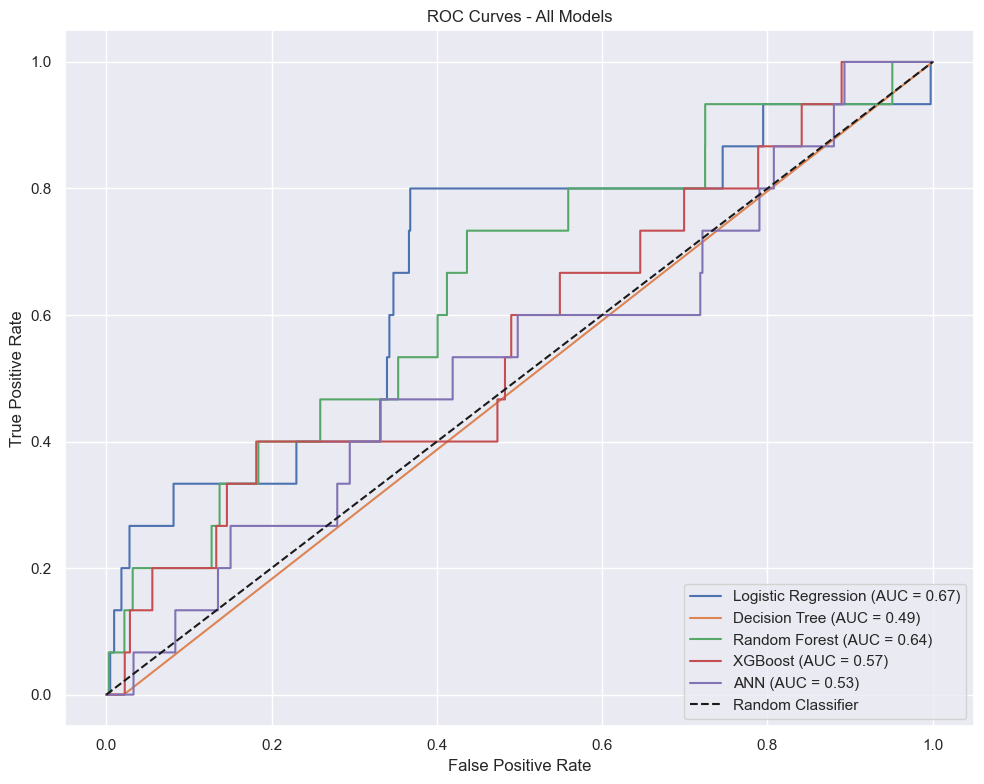

In [28]:
# **ROC Curve Comparison**
# Compute ROC curve data for each model
roc_data = []

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
roc_data.append(("Logistic Regression", fpr, tpr, roc_auc))

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_data.append(("Decision Tree", fpr, tpr, roc_auc_tree))

# Random Forest
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_data.append(("Random Forest", fpr, tpr, roc_auc_rf))

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_data.append(("XGBoost", fpr, tpr, roc_auc_xgb))

# ANN
fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
roc_data.append(("ANN", fpr, tpr, roc_auc_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, fpr, tpr, auc_score in roc_data:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

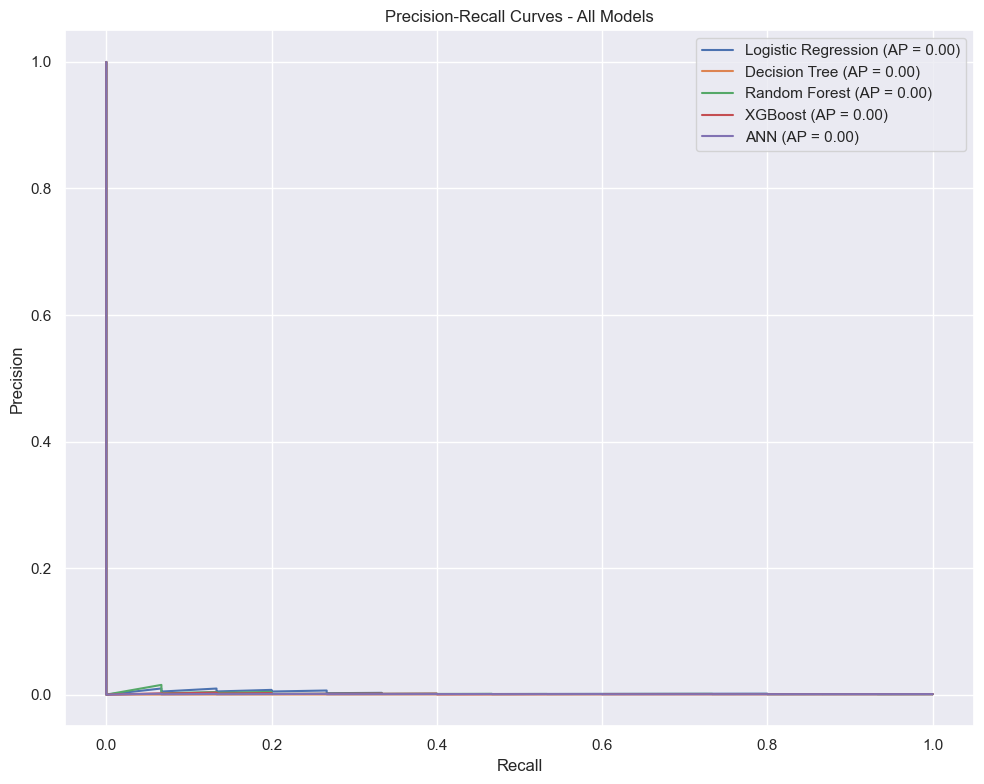

In [29]:
# **Precision Recall Curve**
# Compute Precision-Recall curve data
pr_data = []

# Logistic Regression
precision, recall, _ = precision_recall_curve(y_test, y_proba_logreg)
ap_logreg = average_precision_score(y_test, y_proba_logreg)
pr_data.append(("Logistic Regression", precision, recall, ap_logreg))

# Decision Tree
precision, recall, _ = precision_recall_curve(y_test, y_proba_tree)
ap_tree = average_precision_score(y_test, y_proba_tree)
pr_data.append(("Decision Tree", precision, recall, ap_tree))

# Random Forest
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)
pr_data.append(("Random Forest", precision, recall, ap_rf))

# XGBoost
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
pr_data.append(("XGBoost", precision, recall, ap_xgb))

# ANN
precision, recall, _ = precision_recall_curve(y_test, y_proba_ann)
ap_ann = average_precision_score(y_test, y_proba_ann)
pr_data.append(("ANN", precision, recall, ap_ann))

# Plot
plt.figure(figsize=(10, 8))
for name, precision, recall, ap_score in pr_data:
    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

=== TOP 20 MOST IMPORTANT FEATURES (XGBoost) ===
                                            feature  importance
                           is_first_time_buyer_True    0.180275
                          is_first_time_buyer_False    0.067049
                              seller_city_sao paulo    0.041312
                                    seller_state_sp    0.037988
                                  customer_state_rj    0.034909
                               seller_city_ibitinga    0.033070
         seller_id_7e1fb0a3ebfb01ffb3a7dae98bf3238d    0.028977
product_category_name_english_computers_accessories    0.027663
         seller_id_f457c46070d02cadd8a68551231220dd    0.021534
         seller_id_95f83f51203c626648c875dd41874c7f    0.021121
                              customer_city_arealva    0.018304
         seller_id_c1ed9e3daf6154542826a6996af0fb8c    0.017985
         seller_id_6973a06f484aacf400ece213dbf3d946    0.017656
                            seller_city_santo andre    

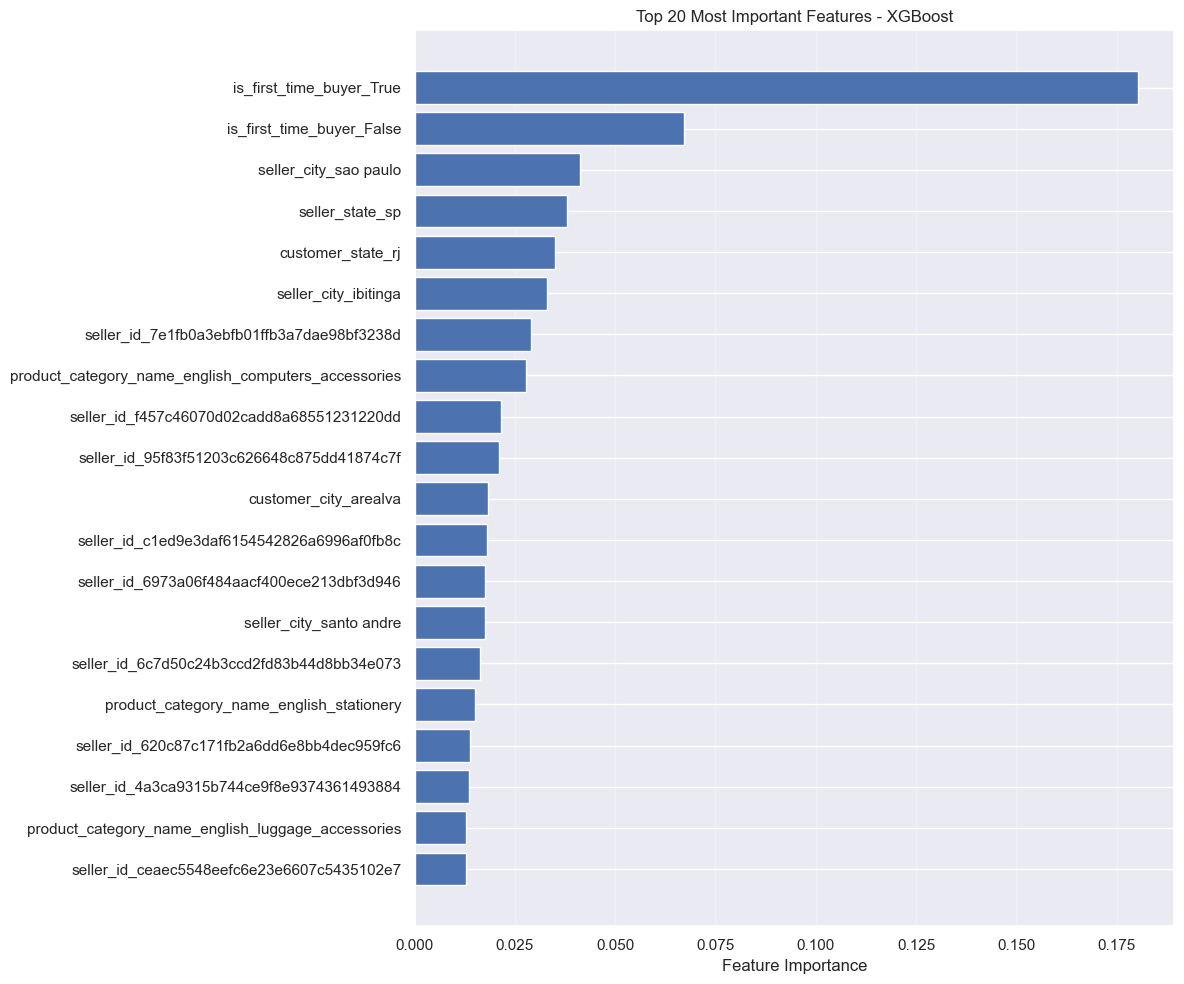

In [18]:
# XGBoost Feature Importance Analysis

# Get feature importance from the trained XGBoost model
feature_importance_xgb = best_xgb.feature_importances_

# Create DataFrame with feature names and importance scores
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importance_xgb
}).sort_values('importance', ascending=False)

# Display top 20 features
print("=== TOP 20 MOST IMPORTANT FEATURES (XGBoost) ===")
top_20_features = feature_importance_df.head(20)
print(top_20_features.to_string(index=False))

# Create visualization
plt.figure(figsize=(12, 10))
plt.barh(range(20), top_20_features['importance'].values[::-1])
plt.yticks(range(20), top_20_features['feature'].values[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features - XGBoost')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()